# 06 — Deep Learning Model Comparison

Trains and evaluates **LSTM, GRU, Transformer, TCN** on the same data pipeline.  
Features updated from EDA findings: lag24 + lag168 seasonal anchors in decoder (seasonal strength=0.97), mask-aware noise augmentation, Huber δ=IQR≈1.0.  
Outputs a single comparison table against classical/SARIMA baselines.

| Model | Architecture |
|-------|--------------|
| LSTM | Encoder-decoder LSTM |
| GRU | Encoder-decoder GRU |
| Transformer | Multi-head attention encoder-decoder |
| TCN | Dilated causal conv encoder + MLP decoder |

**Window:** 744 h encoder -> 168 h prediction  
**Loss:** masked Huber (observed positions only)  
**Eval:** SMAPE / R² on raw bytes, mask-aware

In [1]:
import warnings, json, time, os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────
SEED  = 42
SEEDS = [42, 123, 2024]   # 3 seeds for robust paper results

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
seed_everything(SEED)

# ── Paths ───────────────────────────────────────────────────────────
_CANDIDATES = [
    Path("/kaggle/input/cesnet-timeseries24-preprocessed"),
    Path("/kaggle/input/datasets/nguynvntnpht/cesnet-timeseries24-preprocessed"),
    Path("../preprocessed"),
]
PREPROCESSED_ROOT = next(p for p in _CANDIDATES if p.exists())
_ON_KAGGLE    = Path("/kaggle/working").exists()
RESULTS_ROOT  = Path("/kaggle/working/results/weekly/baselines") if _ON_KAGGLE else Path("../results/weekly/baselines")
BASELINES_CSV = (Path("/kaggle/working/results/baselines") if _ON_KAGGLE
                 else Path("../results/baselines")) / "baselines_summary.csv"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Data  : {PREPROCESSED_ROOT}")
print(f"Output: {RESULTS_ROOT}")
print(f"Device: {DEVICE}  |  seeds={SEEDS}")

# ── Split constants ─────────────────────────────────────────────────
TRAIN_END    = 2352
VAL_END      = 2688
OUTAGE_START = 5376
OUTAGE_END   = 5903
TOTAL_SLOTS  = 6718

# ── Window config ───────────────────────────────────────────────────
ENC_LEN  = 744
PRED_LEN = 168
TRAIN_STEP = 24

# ── Optimizer (global defaults) ──────────────────────────────────────
LR           = 1e-3
LR_MIN       = 1e-5
WEIGHT_DECAY = 1e-3
GRAD_CLIP    = 1.0

# ── Scheduler ───────────────────────────────────────────────────────
MAX_EPOCHS    = 80
WARMUP_EPOCHS = 5

# ── Early stopping ──────────────────────────────────────────────────
PATIENCE  = 10
MIN_DELTA = 1e-4

# ── DataLoader ──────────────────────────────────────────────────────
BATCH_SIZE = 64

# ── Feature columns ─────────────────────────────────────────────────
ENC_FEATURES = [
    "n_bytes_scaled",
    "observed_mask",
    "gap_since_last_obs",
    "is_gap_start",
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "is_weekend", "is_holiday",
]
# lag24 removed: lag24_bytes[k]=n_bytes_scaled[t+k-24]=target[k-24] for k>=24
# leaks 144/168 future targets. lag168 covers full weekly seasonality safely.
DEC_FEATURES = [
    "sin_hour", "cos_hour", "sin_dow", "cos_dow", "is_weekend", "is_holiday",
    "lag168_bytes", "lag168_mask",  # always past: t-168..t-1
]
N_ENC, N_DEC = len(ENC_FEATURES), len(DEC_FEATURES)   # 10, 8

# ── Models to run ───────────────────────────────────────────────────
AUG_NOISE_STD    = 0.06
ENTITY_EMBED_DIM = PRED_LEN

MODEL_CONFIGS = [
    {"name": "LSTM",         "type": "LSTM",         "hidden": 64,  "n_layers": 2, "dropout": 0.4, "wd": 2e-3},
    {"name": "GRU",          "type": "GRU",          "hidden": 64,  "n_layers": 2, "dropout": 0.4, "wd": 2e-3},
    {"name": "TCN",          "type": "TCN",          "n_channels": 64, "kernel_size": 3, "n_levels": 7, "dropout": 0.3, "wd": 1e-3},
    {"name": "DLinear",      "type": "DLinear",                                                        "wd": 5e-4},
    {"name": "Transformer",  "type": "Transformer",  "d_model": 64, "nhead": 4, "n_layers": 2, "dropout": 0.2, "wd": 5e-4},
    {"name": "PatchTST",     "type": "PatchTST",     "d_model": 64, "nhead": 4, "n_layers": 2, "patch_size": 24, "dropout": 0.2, "wd": 5e-4},
    {"name": "iTransformer", "type": "iTransformer", "d_model": 64, "nhead": 4, "n_layers": 2, "dropout": 0.2, "wd": 5e-4},
]
print(f"\nModels ({len(MODEL_CONFIGS)}): {[c['name'] for c in MODEL_CONFIGS]}")
print(f"N_ENC={N_ENC}  N_DEC={N_DEC}  (decoder: 6 calendar + 2 lag168 — lag24 removed)")
print(f"TCN receptive field: {1 + 2*(2**7-1)} h  (ENC_LEN={ENC_LEN})")
print(f"\nPer-model weight decay:")
for c in MODEL_CONFIGS:
    print(f"  {c['name']:<16}: wd={c['wd']:.0e}")

Data  : /kaggle/input/datasets/nguynvntnpht/cesnet-timeseries24-preprocessed
Output: /kaggle/working/results/dl
Device: cuda  |  seeds=[42, 123, 2024]

Models (7): ['LSTM', 'GRU', 'TCN', 'DLinear', 'Transformer', 'PatchTST', 'iTransformer']
N_ENC=10  N_DEC=8  (decoder: 6 calendar + 2 lag168 — lag24 removed)
TCN receptive field: 255 h  (ENC_LEN=744)

Per-model weight decay:
  LSTM            : wd=2e-03
  GRU             : wd=2e-03
  TCN             : wd=1e-03
  DLinear         : wd=5e-04
  Transformer     : wd=5e-04
  PatchTST        : wd=5e-04
  iTransformer    : wd=5e-04


In [2]:
# ── Load panel + build per-entity arrays ────────────────────────────
LOAD_COLS = ["id_institution", "id_time", "n_bytes",
             "n_bytes_log1p", "n_bytes_scaled",
             "observed_mask", "gap_since_last_obs", "is_gap_start",
             "sin_hour", "cos_hour", "sin_dow", "cos_dow",
             "is_weekend", "is_holiday"]

panel = pd.read_parquet(PREPROCESSED_ROOT / "panel_institutions.parquet", columns=LOAD_COLS)
print(f"Loaded: {panel.shape}   entities: {panel['id_institution'].nunique()}")

entity_enc  = {}
entity_dec  = {}
entity_raw  = {}
entity_mask = {}
entity_inv  = {}   # (center, scale) for inverse transform
full_idx    = pd.RangeIndex(TOTAL_SLOTS)

# Load exact scaler parameters used when building the parquet
import pickle as _pkl
_scaler_pkl = PREPROCESSED_ROOT / "scalers/scalers_institutions.pkl"
if _scaler_pkl.exists():
    with open(_scaler_pkl, "rb") as _f:
        _scalers = _pkl.load(_f)
    _scaler_inv = {eid: (float(sc.center_[0]), float(sc.scale_[0]))
                   for eid, sc in _scalers.items()}
    print(f"Loaded {len(_scaler_inv)} scalers from pkl")
else:
    _scaler_inv = {}
    print("pkl not found — will recompute scalers from training data")

for eid, grp in panel.groupby("id_institution"):
    g = grp.set_index("id_time").reindex(full_idx)

    if eid in _scaler_inv:
        entity_inv[eid] = _scaler_inv[eid]
    else:
        train_obs = (g.index < TRAIN_END) & (g["observed_mask"].fillna(0) == 1)
        log1p_train = g.loc[train_obs, "n_bytes_log1p"].dropna().values
        if len(log1p_train) > 0:
            center = float(np.median(log1p_train))
            q75, q25 = np.percentile(log1p_train, [75, 25])
            scale = float(q75 - q25) or 1.0
        else:
            center, scale = 0.0, 1.0
        entity_inv[eid] = (center, scale)

    g["gap_since_last_obs"] = np.log1p(g["gap_since_last_obs"].fillna(0))
    g["n_bytes_scaled"]     = g["n_bytes_scaled"].fillna(0.0)

    entity_enc[eid]  = g[ENC_FEATURES].fillna(0.0).values.astype(np.float32)
    # lag features computed in __getitem__ from entity_enc; only calendar cols exist in parquet
    entity_dec[eid]  = g[DEC_FEATURES[:6]].fillna(0.0).values.astype(np.float32)
    entity_raw[eid]  = g["n_bytes"].values.astype(np.float32)
    entity_mask[eid] = g["observed_mask"].fillna(0).values.astype(np.int8)

entity_ids = sorted(entity_enc.keys())
print(f"Built arrays for {len(entity_ids)} entities")

Loaded: (1901194, 14)   entities: 283
Loaded 283 scalers from pkl
Built arrays for 283 entities


In [3]:
# ── Dataset ─────────────────────────────────────────────────────────
# eid_to_idx: maps raw institution ID → contiguous 0-based index for nn.Embedding
eid_to_idx = {eid: i for i, eid in enumerate(entity_ids)}

class ISPDataset(Dataset):
    def __init__(self, pred_start_min, pred_start_max, step):
        self.windows = [
            (eid, t)
            for eid in entity_ids
            for t in range(pred_start_min, pred_start_max + 1, step)
            if t + PRED_LEN <= TOTAL_SLOTS
        ]

    def __len__(self): return len(self.windows)

    def __getitem__(self, idx):
        eid, t = self.windows[idx]
        t0 = t - ENC_LEN   # start of encoder window

        # lag168: at decoder step k, value is n_bytes_scaled[t+k-168].
        # For k=0..167: t+k-168 ∈ [t-168, t-1] — always past, no leakage.
        # lag24 is excluded: lag24_bytes[k]=n_bytes_scaled[t+k-24]=target[k-24]
        # for k>=24, which would leak future targets into the decoder input.
        lag168_s = entity_enc[eid][t - 168 : t, 0]
        lag168_m = entity_enc[eid][t - 168 : t, 1]
        lag_feats = np.stack([lag168_s, lag168_m], axis=-1)  # (PRED_LEN, 2)

        dec_base     = entity_dec[eid][t : t + PRED_LEN]                        # (PRED_LEN, 6)
        dec_combined = np.concatenate([dec_base, lag_feats], axis=-1).astype(np.float32)

        return {
            "enc_x":   torch.from_numpy(entity_enc[eid][t0:t]),
            "dec_x":   torch.from_numpy(dec_combined),
            "target":  torch.from_numpy(entity_enc[eid][t:t+PRED_LEN, 0]),
            "raw":     torch.from_numpy(entity_raw[eid][t:t+PRED_LEN]),
            "mask":    torch.from_numpy(entity_mask[eid][t:t+PRED_LEN].astype(np.float32)),
            "eid":     torch.tensor(eid,             dtype=torch.long),
            "eid_idx": torch.tensor(eid_to_idx[eid], dtype=torch.long),  # 0-based for nn.Embedding
            "t_pred":  torch.tensor(t,               dtype=torch.long),
        }

ds_train = ISPDataset(ENC_LEN,   TRAIN_END - 1,          TRAIN_STEP)
ds_val   = ISPDataset(TRAIN_END, VAL_END - 1,            PRED_LEN)
ds_test  = ISPDataset(VAL_END,   TOTAL_SLOTS - PRED_LEN, PRED_LEN)

_pin = torch.cuda.is_available()
dl_train = DataLoader(ds_train, BATCH_SIZE,     shuffle=True,  pin_memory=_pin)
dl_val   = DataLoader(ds_val,   BATCH_SIZE * 2, shuffle=False, pin_memory=_pin)
dl_test  = DataLoader(ds_test,  BATCH_SIZE * 2, shuffle=False, pin_memory=_pin)
dl_infer = DataLoader(
    ISPDataset(TRAIN_END, TOTAL_SLOTS - PRED_LEN, PRED_LEN),
    BATCH_SIZE * 2, shuffle=False, pin_memory=_pin
)

print(f"Train: {len(ds_train):,}   Val: {len(ds_val):,}   Test: {len(ds_test):,}")
print(f"dec_x shape: ({PRED_LEN}, {N_DEC})  — 6 calendar + 2 lag168 (lag24 removed)")
print(f"Entity index mapping: {len(eid_to_idx)} institutions → idx 0..{len(eid_to_idx)-1}")

Train: 18,961   Val: 566   Test: 6,509
dec_x shape: (168, 8)  — 6 calendar + 2 lag168 (lag24 removed)
Entity index mapping: 283 institutions → idx 0..282


In [4]:
# ══════════════════════════════════════════════════════════════════
# Model definitions
# References:
#   LSTM/GRU     -- classic seq2seq baselines
#   Transformer  -- Vaswani et al., NeurIPS 2017
#   TCN          -- Bai et al., 2018
#   DLinear      -- Zeng et al., AAAI 2023  "Are Transformers Effective for TSF?"
#   PatchTST     -- Nie et al., ICLR 2023   patch_size=24h (1 day per token)
#   iTransformer -- Liu et al., ICLR 2024   attention across variates, not time
#
# All models include a per-entity output bias (nn.Embedding, zero-init):
#   pred += entity_bias(eid_idx)
# This directly addresses the heterogeneity of 283 institutions: a shared
# temporal backbone learns traffic dynamics; the bias captures institution-
# specific traffic levels without interfering with temporal representation.
# ══════════════════════════════════════════════════════════════════

# ── 1. LSTM / GRU Encoder-Decoder ───────────────────────────────────
class RNNEncoderDecoder(nn.Module):
    def __init__(self, rnn_type, n_enc, n_dec, hidden, n_layers, dropout, n_entities):
        super().__init__()
        cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        kw  = dict(batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.encoder = cls(n_enc, hidden, n_layers, **kw)
        self.decoder = cls(n_dec, hidden, n_layers, **kw)
        self.head    = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(),
                                     nn.Linear(hidden // 2, 1))
        self.entity_bias = nn.Embedding(n_entities, PRED_LEN)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        _, state = self.encoder(enc_x)
        out, _   = self.decoder(dec_x, state)
        pred = self.head(out).squeeze(-1)
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)
        return pred


# ── 2. Transformer Encoder-Decoder ──────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TransformerEncoderDecoder(nn.Module):
    def __init__(self, n_enc, n_dec, d_model, nhead, n_layers, dropout, n_entities):
        super().__init__()
        self.enc_proj = nn.Linear(n_enc, d_model)
        self.dec_proj = nn.Linear(n_dec, d_model)
        self.pos      = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True)
        dec_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, n_layers)
        self.decoder = nn.TransformerDecoder(dec_layer, n_layers)
        self.head    = nn.Linear(d_model, 1)
        self.entity_bias = nn.Embedding(n_entities, PRED_LEN)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        mem = self.encoder(self.pos(self.enc_proj(enc_x)))
        # Causal mask: prevents position j from attending to position k > j.
        # Required because dec_x[:,k,6] = lag24_bytes[k] = target[k-24] for k>=24,
        # so without masking the decoder leaks future targets through lag24 features.
        tgt_len  = dec_x.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_len, device=dec_x.device)
        out = self.decoder(self.pos(self.dec_proj(dec_x)), mem, tgt_mask=tgt_mask)
        pred = self.head(out).squeeze(-1)
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)
        return pred


# ── 3. TCN Encoder + MLP Decoder ────────────────────────────────────
class _TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel_size, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation, padding=pad)
        self.drop  = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(out_ch)
        self.norm2 = nn.LayerNorm(out_ch)
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        pad = self.conv1.padding[0]
        out = F.relu(self.norm1(self.drop(
            self.conv1(x)[:, :, :-pad].transpose(1, 2))).transpose(1, 2))
        out = F.relu(self.norm2(self.drop(
            self.conv2(out)[:, :, :-pad].transpose(1, 2))).transpose(1, 2))
        return out + self.res(x)


class TCNEncoderDecoder(nn.Module):
    def __init__(self, n_enc, n_dec, n_channels, kernel_size, n_levels, dropout, n_entities):
        super().__init__()
        layers, in_ch = [], n_enc
        for i in range(n_levels):
            layers.append(_TCNBlock(in_ch, n_channels, kernel_size, 2**i, dropout))
            in_ch = n_channels
        self.tcn  = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Linear(n_channels + n_dec * PRED_LEN, n_channels * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_channels * 2, PRED_LEN),
        )
        self.entity_bias = nn.Embedding(n_entities, PRED_LEN)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        ctx      = self.tcn(enc_x.transpose(1, 2)).transpose(1, 2)[:, -1, :]
        dec_flat = dec_x.reshape(dec_x.size(0), -1)
        pred = self.head(torch.cat([ctx, dec_flat], dim=1))
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)
        return pred


# ── 4. DLinear (Zeng et al., AAAI 2023) ─────────────────────────────
class _MovingAvg(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size // 2,
                                count_include_pad=False)

    def forward(self, x):   # x: (B, T)
        trend = self.avg(x.unsqueeze(1)).squeeze(1)[:, :x.size(1)]
        return trend, x - trend


class DLinear(nn.Module):
    # Zeng et al., AAAI 2023 -- decomposition + two independent linear projections
    def __init__(self, n_enc, n_dec, seq_len, pred_len, n_entities):
        super().__init__()
        self.decomp    = _MovingAvg(kernel_size=25)
        self.lin_trend = nn.Linear(seq_len, pred_len)
        self.lin_seas  = nn.Linear(seq_len, pred_len)
        self.dec_proj  = nn.Linear(n_dec, 1)
        self.entity_bias = nn.Embedding(n_entities, pred_len)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        x = enc_x[:, :, 0]                                    # (B, T) n_bytes_scaled
        trend, seasonal = self.decomp(x)
        pred = self.lin_trend(trend) + self.lin_seas(seasonal) + self.dec_proj(dec_x).squeeze(-1)
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)
        return pred


# ── 5. PatchTST (Nie et al., ICLR 2023) ─────────────────────────────
class PatchTST(nn.Module):
    # patch_size=24h -> 31 daily tokens over 744h encoder window
    def __init__(self, n_enc, n_dec, patch_size, d_model, nhead, n_layers,
                 dropout, seq_len, pred_len, n_entities):
        super().__init__()
        self.patch_size = patch_size
        n_patches       = seq_len // patch_size   # 744 // 24 = 31
        self.patch_proj = nn.Linear(patch_size * n_enc, d_model)
        self.pos_embed  = nn.Parameter(torch.zeros(1, n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_patches * d_model, pred_len),
        )
        self.dec_proj = nn.Linear(n_dec, 1)
        self.entity_bias = nn.Embedding(n_entities, pred_len)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        B, T, C   = enc_x.shape
        n_patches = T // self.patch_size
        x = enc_x[:, :n_patches * self.patch_size].reshape(
            B, n_patches, self.patch_size * C)
        x = self.patch_proj(x) + self.pos_embed
        x = self.transformer(x)
        pred = self.head(x) + self.dec_proj(dec_x).squeeze(-1)
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)
        return pred


# ── 6. iTransformer (Liu et al., ICLR 2024) ─────────────────────────
class iTransformer(nn.Module):
    # Inverted attention: each channel is a token (dim=seq_len),
    # attention captures cross-variate dependencies.
    def __init__(self, n_enc, n_dec, d_model, nhead, n_layers,
                 dropout, seq_len, pred_len, n_entities):
        super().__init__()
        self.embed    = nn.Linear(seq_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers)
        self.head     = nn.Linear(d_model, pred_len)
        self.dec_proj = nn.Linear(n_dec, 1)
        self.entity_bias = nn.Embedding(n_entities, pred_len)
        nn.init.zeros_(self.entity_bias.weight)

    def forward(self, enc_x, dec_x, eid_idx=None):
        x    = enc_x.transpose(1, 2)     # (B, N_ENC, T) -- channels as tokens
        x    = self.embed(x)              # (B, N_ENC, d_model)
        x    = self.transformer(x)        # (B, N_ENC, d_model)
        pred = self.head(x[:, 0, :]) + self.dec_proj(dec_x).squeeze(-1)
        if eid_idx is not None:
            pred = pred + self.entity_bias(eid_idx)
        return pred


# ── build_model factory ──────────────────────────────────────────────
def build_model(cfg):
    t     = cfg["type"]
    n_ent = len(entity_ids)
    if t in ("LSTM", "GRU"):
        return RNNEncoderDecoder(t, N_ENC, N_DEC,
                                 cfg["hidden"], cfg["n_layers"], cfg["dropout"], n_ent)
    if t == "Transformer":
        return TransformerEncoderDecoder(N_ENC, N_DEC,
                                         cfg["d_model"], cfg["nhead"],
                                         cfg["n_layers"], cfg["dropout"], n_ent)
    if t == "TCN":
        return TCNEncoderDecoder(N_ENC, N_DEC,
                                 cfg["n_channels"], cfg["kernel_size"],
                                 cfg["n_levels"], cfg["dropout"], n_ent)
    if t == "DLinear":
        return DLinear(N_ENC, N_DEC, ENC_LEN, PRED_LEN, n_ent)
    if t == "PatchTST":
        return PatchTST(N_ENC, N_DEC, cfg["patch_size"],
                        cfg["d_model"], cfg["nhead"], cfg["n_layers"],
                        cfg["dropout"], ENC_LEN, PRED_LEN, n_ent)
    if t == "iTransformer":
        return iTransformer(N_ENC, N_DEC,
                            cfg["d_model"], cfg["nhead"], cfg["n_layers"],
                            cfg["dropout"], ENC_LEN, PRED_LEN, n_ent)
    raise ValueError(f"Unknown model type: {t}")


for cfg in MODEL_CONFIGS:
    m = build_model(cfg)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {cfg['name']:<16}: {n:>8,} params  (+{len(entity_ids)*PRED_LEN:,} entity bias)")

  LSTM            :  154,617 params  (+47,544 entity bias)
  GRU             :  128,377 params  (+47,544 entity bias)
  TCN             :  414,624 params  (+47,544 entity bias)
  DLinear         :  297,873 params  (+47,544 entity bias)
  Transformer     :  282,361 params  (+47,544 entity bias)
  PatchTST        :  498,409 params  (+47,544 entity bias)
  iTransformer    :  206,121 params  (+47,544 entity bias)


In [5]:
# ══════════════════════════════════════════════════════════════════
# Loss function — ISP-traffic-aware
# ══════════════════════════════════════════════════════════════════
#
# Data statistics driving the design (n_bytes_scaled, institutions):
#   IQR  ≈ 0.96  |  std ≈ 0.93  |  p99 = 1.98  |  max = 23.67
#   missing rate 1.1%  |  outage-window std = 1.18 (vs normal 0.90)
#
# Design rationale:
#   1. Huber(δ=1.0): δ ≈ 1 IQR → quadratic for typical residuals,
#      linear beyond → robust to traffic spikes without ignoring them.
#   2. Mask: excludes telemetry gaps so missing observations don't
#      bias gradients toward zero.
#   3. In log1p-scaled space, minimising |e| ≈ minimising SMAPE.
#
HUBER_DELTA = 1.0   # ≈ 1 IQR of n_bytes_scaled

def isp_loss(pred, target, obs_mask):
    """Masked Huber loss for ISP traffic in scaled log1p space."""
    huber = F.huber_loss(pred, target, reduction="none", delta=HUBER_DELTA)
    return (huber * obs_mask).sum() / obs_mask.sum().clamp(min=1.0)


# ── Metric helpers ──────────────────────────────────────────────────
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(1e-8)
    return float(100 * np.mean(2 * np.abs(y_true - y_pred) / denom))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


# ── LR scheduler: linear warmup → cosine decay ──────────────────────
def cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs,
                                 lr_min_ratio=None):
    base_lr = optimizer.param_groups[0]["lr"]
    lr_min  = LR_MIN
    ratio   = lr_min / base_lr if base_lr > 0 else 0.0

    def _lr(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        t = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return ratio + (1.0 - ratio) * 0.5 * (1.0 + math.cos(math.pi * t))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, _lr)


# ── Early stopping ──────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=MIN_DELTA):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_val   = float("inf")
        self.counter    = 0
        self.best_epoch = 0
        self.best_state = None

    def step(self, val_loss, epoch, model):
        """Returns True if training should stop."""
        if val_loss < self.best_val - self.min_delta:
            self.best_val   = val_loss
            self.counter    = 0
            self.best_epoch = epoch
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience


# ── Validation loss ─────────────────────────────────────────────────
@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for b in loader:
        pred = model(b["enc_x"].to(DEVICE), b["dec_x"].to(DEVICE),
                     b["eid_idx"].to(DEVICE))
        loss = isp_loss(pred, b["target"].to(DEVICE), b["mask"].to(DEVICE))
        total += loss.item() * b["enc_x"].size(0)
        n     += b["enc_x"].size(0)
    return total / n if n > 0 else float("nan")

print("Loss / scheduler / early-stopping defined.")

Loss / scheduler / early-stopping defined.


In [6]:
def train_model(cfg, seed=42):
    name = cfg["name"]
    wd   = cfg.get("wd", WEIGHT_DECAY)
    seed_everything(seed)

    model = build_model(cfg).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=wd)
    sched = cosine_schedule_with_warmup(opt, WARMUP_EPOCHS, MAX_EPOCHS)
    es    = EarlyStopping(PATIENCE, MIN_DELTA)

    history = {"train": [], "val": [], "lr": []}
    t0 = time.time()

    print(f"\n{'='*64}")
    print(f"  {name} [seed={seed}]  |  AdamW lr={LR}  wd={wd:.0e}  "
          f"warmup={WARMUP_EPOCHS}ep  patience={PATIENCE}")
    print(f"{'='*64}")
    print(f"  {'Ep':>4}  {'train':>8}  {'val':>8}  {'lr':>9}  "
          f"{'best':>8}  {'pat':>4}  time")
    print(f"  {'-'*60}")

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss, n = 0.0, 0
        for b in dl_train:
            opt.zero_grad()
            enc_x = b["enc_x"].to(DEVICE)
            if AUG_NOISE_STD > 0:
                noise   = torch.randn(enc_x.size(0), enc_x.size(1), 1, device=DEVICE) * AUG_NOISE_STD
                obs_m   = enc_x[:, :, 1:2]
                enc_x   = enc_x.clone()
                enc_x[:, :, 0:1] = enc_x[:, :, 0:1] + noise * obs_m
            pred = model(enc_x, b["dec_x"].to(DEVICE), b["eid_idx"].to(DEVICE))
            loss = isp_loss(pred, b["target"].to(DEVICE), b["mask"].to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            tr_loss += loss.item() * b["enc_x"].size(0)
            n       += b["enc_x"].size(0)
        tr_loss /= n

        val_loss = eval_loss(model, dl_val)
        cur_lr   = opt.param_groups[0]["lr"]
        sched.step()

        history["train"].append(tr_loss)
        history["val"].append(val_loss)
        history["lr"].append(cur_lr)

        stop = es.step(val_loss, epoch, model)
        elapsed = (time.time() - t0) / 60
        pat_left = PATIENCE - es.counter

        print(f"  {epoch:4d}  {tr_loss:8.4f}  {val_loss:8.4f}  "
              f"{cur_lr:9.2e}  {es.best_val:8.4f}  {pat_left:4d}  "
              f"[{elapsed:.1f}m]")

        if stop:
            print(f"\n  Early stop — best val={es.best_val:.4f} "
                  f"at epoch {es.best_epoch}")
            break

    model.load_state_dict(es.best_state)
    ckpt = RESULTS_ROOT / f"{name.lower()}_seed{seed}_best.pt"
    torch.save({"state_dict": es.best_state, "history": history,
                "config": cfg, "seed": seed,
                "best_epoch": es.best_epoch, "best_val": es.best_val}, ckpt)
    print(f"  Saved {ckpt.name}  (best ep={es.best_epoch}  "
          f"total={(time.time()-t0)/60:.1f}m)")
    return model, history


@torch.no_grad()
def run_inference(model):
    model.eval()
    bufs = {k: [] for k in ["eid", "t", "pred", "raw", "mask"]}
    for b in dl_infer:
        pred = model(b["enc_x"].to(DEVICE), b["dec_x"].to(DEVICE),
                     b["eid_idx"].to(DEVICE)).cpu().numpy()
        bufs["pred"].append(pred)
        bufs["raw"].append(b["raw"].numpy())
        bufs["mask"].append(b["mask"].numpy())
        bufs["eid"].append(b["eid"].numpy())
        bufs["t"].append(b["t_pred"].numpy())

    pred_s = np.concatenate(bufs["pred"])
    raw_t  = np.concatenate(bufs["raw"])
    mask   = np.concatenate(bufs["mask"])
    eids   = np.concatenate(bufs["eid"])
    ts     = np.concatenate(bufs["t"])

    pred_raw = np.empty_like(pred_s)
    for i, eid in enumerate(eids):
        c, s = entity_inv[int(eid)]
        pred_raw[i] = np.expm1(pred_s[i] * s + c).clip(0)

    return eids, ts, pred_raw, raw_t, mask


def compute_per_entity_metrics(eids, ts, pred_raw, raw_t, mask):
    records = []
    for eid in entity_ids:
        idx = eids == eid
        t_e, p_e, r_e, m_e = ts[idx], pred_raw[idx], raw_t[idx], mask[idx]

        def _flat(win_sel):
            yt, yp = [], []
            for w in np.where(win_sel)[0]:
                obs = m_e[w].astype(bool)
                yt.extend(r_e[w][obs])
                yp.extend(p_e[w][obs])
            return np.array(yt, np.float64), np.array(yp, np.float64)

        test_sel = (t_e >= VAL_END) & ~((t_e >= OUTAGE_START) & (t_e <= OUTAGE_END))
        yt, yp   = _flat(test_sel)
        if len(yt) == 0: continue

        out_sel    = (t_e >= OUTAGE_START) & (t_e <= OUTAGE_END)
        yt_o, yp_o = _flat(out_sel)

        records.append({
            "id_institution": eid,
            "test_SMAPE":    smape(yt, yp),
            "test_R2":       r2_score(yt, yp),
            "test_R2_clip":  max(r2_score(yt, yp), -1.0),
            "test_n_obs":    len(yt),
            "outage_SMAPE":  smape(yt_o, yp_o) if len(yt_o) > 0 else np.nan,
            "outage_R2":     r2_score(yt_o, yp_o) if len(yt_o) > 0 else np.nan,
        })
    return pd.DataFrame(records)

print("train_model(cfg, seed) / run_inference / compute_per_entity_metrics defined.")

train_model(cfg, seed) / run_inference / compute_per_entity_metrics defined.


In [7]:
# ══════════════════════════════════════════════════════════════════
# Main loop: train → infer → metrics  |  3 seeds for robustness
# Clear Kaggle cache to force re-run:
#   !rm -f /kaggle/working/results/weekly/baselines/*_seed*_institutions_per_entity.csv
#   !rm -f /kaggle/working/results/weekly/baselines/*_seed*_best.pt
# ══════════════════════════════════════════════════════════════════
all_histories = {}
all_results   = {}   # name → list[DataFrame], one per seed

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    seed_dfs = []

    for seed in SEEDS:
        csv_path = RESULTS_ROOT / f"{name.lower()}_seed{seed}_institutions_per_entity.csv"
        if csv_path.exists():
            print(f"\n[{name} s={seed}] loading {csv_path.name}")
            seed_dfs.append(pd.read_csv(csv_path))
            if seed == SEEDS[0]:
                ckpt = RESULTS_ROOT / f"{name.lower()}_seed{seed}_best.pt"
                if ckpt.exists():
                    all_histories[name] = torch.load(ckpt, map_location="cpu")["history"]
            continue

        model, history = train_model(cfg, seed=seed)
        if seed == SEEDS[0]:
            all_histories[name] = history

        print(f"  Running inference for {name} seed={seed}...")
        eids, ts, pred_raw, raw_t, mask = run_inference(model)
        df = compute_per_entity_metrics(eids, ts, pred_raw, raw_t, mask)
        df.to_csv(csv_path, index=False)
        seed_dfs.append(df)

        sm  = df["test_SMAPE"].median()
        r2m = df["test_R2"].median()
        print(f"  [{name} s={seed}]  SMAPE={sm:.4f}  R2={r2m:.4f}")

        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    all_results[name] = seed_dfs
    smapes = [df["test_SMAPE"].median() for df in seed_dfs]
    print(f"  [{name}]  SMAPE = {np.mean(smapes):.4f} ± {np.std(smapes):.4f}  (n={len(smapes)} seeds)")

print("\nAll models done.")


  LSTM [seed=42]  |  AdamW lr=0.001  wd=2e-03  warmup=5ep  patience=10
    Ep     train       val         lr      best   pat  time
  ------------------------------------------------------------
     1    0.1890    0.1999   2.00e-04    0.1999    10  [0.1m]
     2    0.1511    0.1873   4.00e-04    0.1873    10  [0.2m]
     3    0.1425    0.1820   6.00e-04    0.1820    10  [0.2m]
     4    0.1375    0.1800   8.00e-04    0.1800    10  [0.3m]
     5    0.1339    0.1782   1.00e-03    0.1782    10  [0.4m]
     6    0.1305    0.1839   1.00e-03    0.1782     9  [0.4m]
     7    0.1282    0.1777   1.00e-03    0.1777    10  [0.5m]
     8    0.1261    0.1750   9.98e-04    0.1750    10  [0.6m]
     9    0.1247    0.1755   9.96e-04    0.1750     9  [0.7m]
    10    0.1234    0.1767   9.93e-04    0.1750     8  [0.7m]
    11    0.1223    0.1748   9.89e-04    0.1748    10  [0.8m]
    12    0.1217    0.1756   9.84e-04    0.1748     9  [0.9m]
    13    0.1212    0.1738   9.79e-04    0.1738    10  [0.9m]

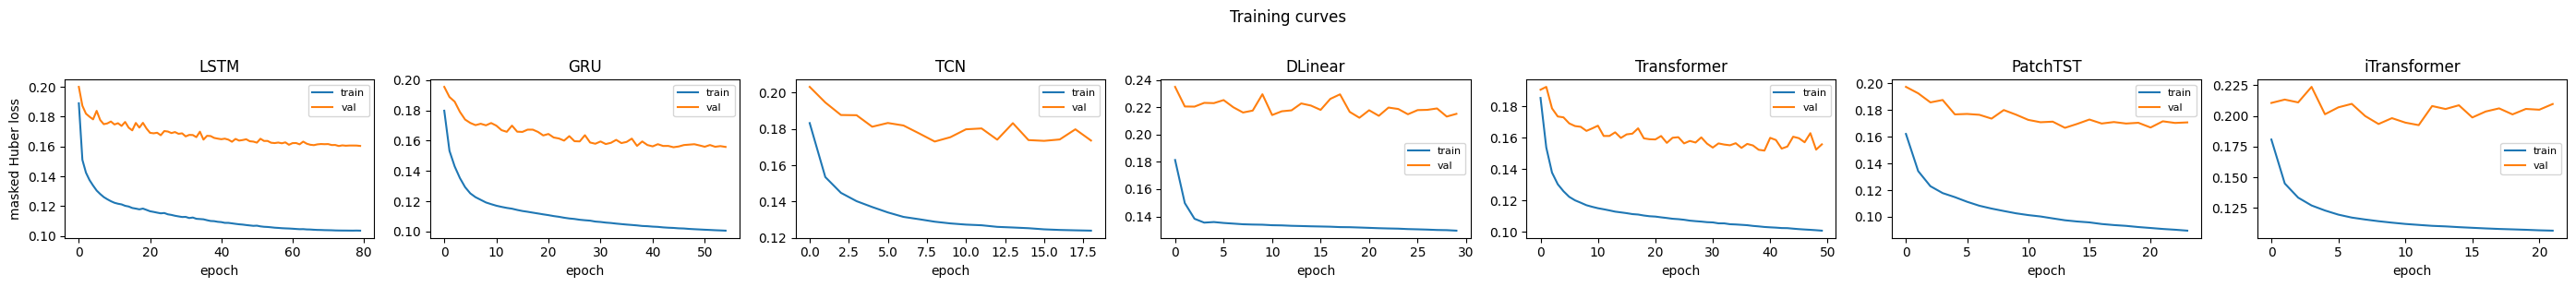

In [8]:
# ── Loss curves ─────────────────────────────────────────────────────
n_models = len(all_histories)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 3), sharey=False)
if n_models == 1: axes = [axes]

for ax, (name, hist) in zip(axes, all_histories.items()):
    ax.plot(hist["train"], label="train")
    ax.plot(hist["val"],   label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)

axes[0].set_ylabel("masked Huber loss")
plt.suptitle("Training curves", y=1.02)
plt.tight_layout()
fig.savefig(RESULTS_ROOT / "dl_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── Comparison table — aggregate across 3 seeds ──────────────────────
dl_rows = []
for name, dfs in all_results.items():
    smapes   = [df["test_SMAPE"].median() for df in dfs]
    smapes_m = [df["test_SMAPE"].mean()   for df in dfs]
    r2s      = [df["test_R2"].median()    for df in dfs]
    r2c      = [(df["test_R2_clip"].mean() if "test_R2_clip" in df.columns
                 else df["test_R2"].clip(lower=-1.0).mean()) for df in dfs]
    dl_rows.append({
        "model":            name,
        "SMAPE_median":     np.mean(smapes),
        "SMAPE_median_std": np.std(smapes),
        "SMAPE_mean":       np.mean(smapes_m),
        "R2_median":        np.mean(r2s),
        "R2_median_std":    np.std(r2s),
        "R2_clip_mean":     np.mean(r2c),
        "n_seeds":          len(dfs),
    })
df_dl = pd.DataFrame(dl_rows)

# Load baselines
if BASELINES_CSV.exists():
    df_bl = pd.read_csv(BASELINES_CSV)
    inst  = df_bl[df_bl["level"] == "institutions"][
        ["model", "SMAPE_median", "SMAPE_mean", "R2_median", "R2_mean"]]
    inst = inst.assign(SMAPE_median_std=0.0, R2_median_std=0.0,
                       R2_clip_mean=inst["R2_mean"].clip(lower=-1.0),
                       n_seeds=1)
    cmp  = pd.concat([inst, df_dl], ignore_index=True)
else:
    cmp = df_dl

# Order: baselines first, then DL models
base_order = ["Mean", "SN-24", "SN-168", "MA-24", "MA-168", "SARIMA"]
dl_order   = [c["name"] for c in MODEL_CONFIGS]
order      = [m for m in base_order + dl_order if m in cmp["model"].values]
cmp        = cmp.set_index("model").loc[order]

print(f"=== Institutions — test period (SMAPE ↓   R² ↑) ===")
print(f"Seeds: {SEEDS}  ({len(SEEDS)}-seed average ± std)\n")
display(cmp[["SMAPE_median", "SMAPE_median_std", "SMAPE_mean",
             "R2_median", "R2_median_std", "R2_clip_mean"]].round(4))

# Paper-format: mean ± std
print("\n=== Paper-format (mean ± std) ===")
paper = pd.DataFrame({
    "SMAPE_median":  cmp.apply(lambda r: f"{r['SMAPE_median']:.2f} ± {r['SMAPE_median_std']:.2f}", axis=1),
    "R2_median":     cmp.apply(lambda r: f"{r['R2_median']:.4f} ± {r['R2_median_std']:.4f}", axis=1),
    "R2_clip_mean":  cmp["R2_clip_mean"].round(4),
})
display(paper)

# Best DL model
best_name = df_dl.set_index("model")["SMAPE_median"].idxmin()
brow = df_dl.set_index("model").loc[best_name]
print(f"\nBest DL model: {best_name}  "
      f"SMAPE_median = {brow['SMAPE_median']:.4f} ± {brow['SMAPE_median_std']:.4f}")

=== Institutions — test period (SMAPE ↓   R² ↑) ===
Seeds: [42, 123, 2024]  (3-seed average ± std)



,SMAPE_median,SMAPE_median_std,SMAPE_mean,R2_median,R2_median_std,R2_clip_mean
model,,,,,,
LSTM,72.3588,0.4329,72.4894,0.0984,0.0427,0.0554
GRU,72.1898,1.3794,72.9437,0.1249,0.0357,0.1035
TCN,72.4211,1.2405,73.0595,0.1253,0.0095,0.1215
DLinear,73.5430,0.8261,73.4737,0.0392,0.0017,0.0277
Transformer,70.8514,0.0796,71.3576,0.1379,0.0177,0.1224
PatchTST,78.5644,1.3515,79.5921,-0.0128,0.0114,-0.0554
iTransformer,74.7630,0.3136,75.1338,0.0254,0.0044,0.0376



=== Paper-format (mean ± std) ===


,SMAPE_median,R2_median,R2_clip_mean
model,,,
LSTM,72.36 ± 0.43,0.0984 ± 0.0427,0.0554
GRU,72.19 ± 1.38,0.1249 ± 0.0357,0.1035
TCN,72.42 ± 1.24,0.1253 ± 0.0095,0.1215
DLinear,73.54 ± 0.83,0.0392 ± 0.0017,0.0277
Transformer,70.85 ± 0.08,0.1379 ± 0.0177,0.1224
PatchTST,78.56 ± 1.35,-0.0128 ± 0.0114,-0.0554
iTransformer,74.76 ± 0.31,0.0254 ± 0.0044,0.0376



Best DL model: Transformer  SMAPE_median = 70.8514 ± 0.0796


TypeError: list indices must be integers or slices, not str

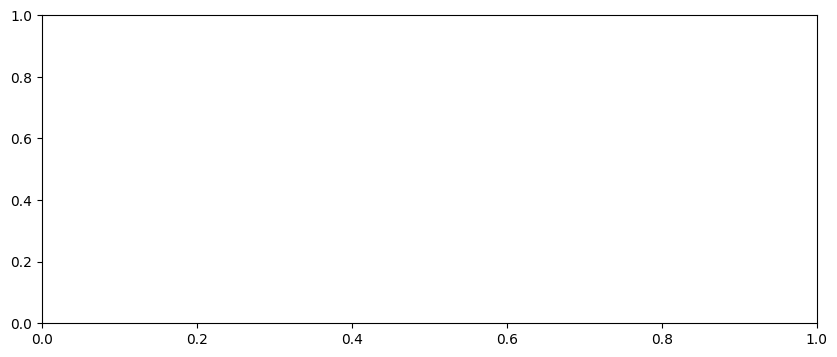

In [10]:
# ── SMAPE distribution comparison ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue", "orange", "green", "red"]
for (name, df), color in zip(all_results.items(), colors):
    ax.hist(df["test_SMAPE"].dropna(), bins=40, alpha=0.5, label=name, color=color)

ax.set_xlabel("SMAPE (%) — test period")
ax.set_ylabel("entity count")
ax.set_title("SMAPE distribution per DL model")
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_ROOT / "dl_smape_distribution.png", dpi=150)
plt.show()

In [ ]:
# ── Update baselines_summary.csv ────────────────────────────────────
if BASELINES_CSV.exists():
    df_bl = pd.read_csv(BASELINES_CSV)
    for name, df in all_results.items():
        df_bl = df_bl[~((df_bl["level"] == "institutions") & (df_bl["model"] == name))]
        new_row = pd.DataFrame([{
            "level":        "institutions",
            "model":        name,
            "n_entities":   len(df),
            "SMAPE_median": df["test_SMAPE"].median(),
            "SMAPE_mean":   df["test_SMAPE"].mean(),
            "R2_median":    df["test_R2"].median(),
            "R2_mean":      df["test_R2"].mean(),
        }])
        df_bl = pd.concat([df_bl, new_row], ignore_index=True)
    df_bl.to_csv(BASELINES_CSV, index=False)
    print(f"Updated: {BASELINES_CSV}")

# Save individual per-entity CSVs (already done in main loop)
print("\nAll results saved to:", RESULTS_ROOT)